# Model Training
**Mục tiêu**: Train Random Forest Regressor (dự đoán doanh số) + KMeans Clustering (phân khúc sách).

- Input: `data/processed/data_ml.csv`, `data/processed/data_eda.csv`
- Output: Model artifacts → `notebooks/model/artifacts/`


In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print("Libraries loaded ✓")


Libraries loaded ✓


---
## 1. Load Processed Data


In [2]:
df_ml = pd.read_csv("../../data/processed/data_ml.csv")
metadata = joblib.load("../../data/processed/ml_metadata.pkl")

ml_features = metadata['features']
top_publishers = metadata['top_publishers']
top_cats = metadata['top_cats']

print(f"ML data shape: {df_ml.shape}")
print(f"Number of features: {len(ml_features)}")
print(f"Target: log_sales")
print(f"\nFeature list:")
for i, f in enumerate(ml_features, 1):
    print(f"  {i:2d}. {f}")


ML data shape: (132955, 21)
Number of features: 20
Target: log_sales

Feature list:
   1. price
   2. discount_rate_norm
   3. rating_average
   4. number_of_page
   5. log_review_count
   6. is_high_rating
   7. is_heavy_book
   8. publisher_vn_mapped_1980 Books
   9. publisher_vn_mapped_AZ Việt Nam
  10. publisher_vn_mapped_Alpha Books
  11. publisher_vn_mapped_Alphabooks
  12. publisher_vn_mapped_First News - Trí Việt
  13. publisher_vn_mapped_NXB Trẻ
  14. publisher_vn_mapped_Nhà Sách Hồng Ân
  15. publisher_vn_mapped_Nhà Xuất Bản Kim Đồng
  16. publisher_vn_mapped_Nhã Nam
  17. publisher_vn_mapped_Other
  18. publisher_vn_mapped_Thái Hà
  19. cat_level_2_mapped_sach-tieng-anh
  20. cat_level_2_mapped_sach-truyen-tieng-viet


In [3]:
df_ml.describe()


,price,discount_rate_norm,rating_average,number_of_page,log_review_count,is_high_rating,is_heavy_book,log_sales
count,132955.000000,132955.000000,132955.000000,132955.0,132955.000000,132955.000000,132955.0,132955.000000
mean,0.198657,0.672670,1.143218,0.0,0.422002,0.206634,0.0,1.231466
std,0.815807,1.054962,2.060529,0.0,0.974912,0.404892,0.0,1.700202
min,-1.013534,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
25%,-0.412030,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
50%,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.693147
75%,0.587970,1.000000,0.000000,0.0,0.000000,0.000000,0.0,1.945910
max,2.087970,10.000000,5.000000,0.0,8.889860,1.000000,0.0,11.229010


---
## 2. Train/Test Split


In [4]:
X = df_ml[ml_features]
y = df_ml['log_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"\nTarget distribution:")
print(f"  Train - mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"  Test  - mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")


Train set: (106364, 20)
Test set:  (26591, 20)

Target distribution:
  Train - mean: 1.232, std: 1.700
  Test  - mean: 1.230, std: 1.700


---
## 3. Train Random Forest Regressor


### 3.1 Lý do chọn Random Forest:
- **Không cần scale** (tree-based model)
- **Bắt được non-linear relationships** tốt
- **Có feature importance** built-in → giải thích được
- **Nhanh, ít hyperparameter** cần tune
- **Chống overfitting** tốt hơn single Decision Tree


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=100,     # 100 cây
    max_depth=10,         # Giới hạn độ sâu → tránh overfitting
    min_samples_split=5,  # Tối thiểu 5 samples để split
    min_samples_leaf=2,   # Tối thiểu 2 samples ở leaf
    random_state=42,
    n_jobs=-1             # Dùng tất cả CPU cores
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print("✓ Training complete!")


Training Random Forest...
✓ Training complete!


### 3.2 Quick Evaluation


In [6]:
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

print("=== Random Forest Performance ===")
print(f"\n{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'RMSE':<20} {root_mean_squared_error(y_train, y_pred_train):>10.4f} {root_mean_squared_error(y_test, y_pred_test):>10.4f}")
print(f"{'R²':<20} {r2_score(y_train, y_pred_train):>10.4f} {r2_score(y_test, y_pred_test):>10.4f}")
print(f"{'MAE':<20} {mean_absolute_error(y_train, y_pred_train):>10.4f} {mean_absolute_error(y_test, y_pred_test):>10.4f}")

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
if train_r2 - test_r2 > 0.1:
    print(f"\n⚠️ Gap R² = {train_r2 - test_r2:.4f} → có dấu hiệu overfitting nhẹ")
else:
    print(f"\n✓ Gap R² = {train_r2 - test_r2:.4f} → model ổn định")


=== Random Forest Performance ===

Metric                    Train       Test
------------------------------------------
RMSE                     0.7079     0.7342
R²                       0.8267     0.8136
MAE                      0.5306     0.5449

✓ Gap R² = 0.0131 → model ổn định


### 3.3 Feature Importance (sơ bộ)


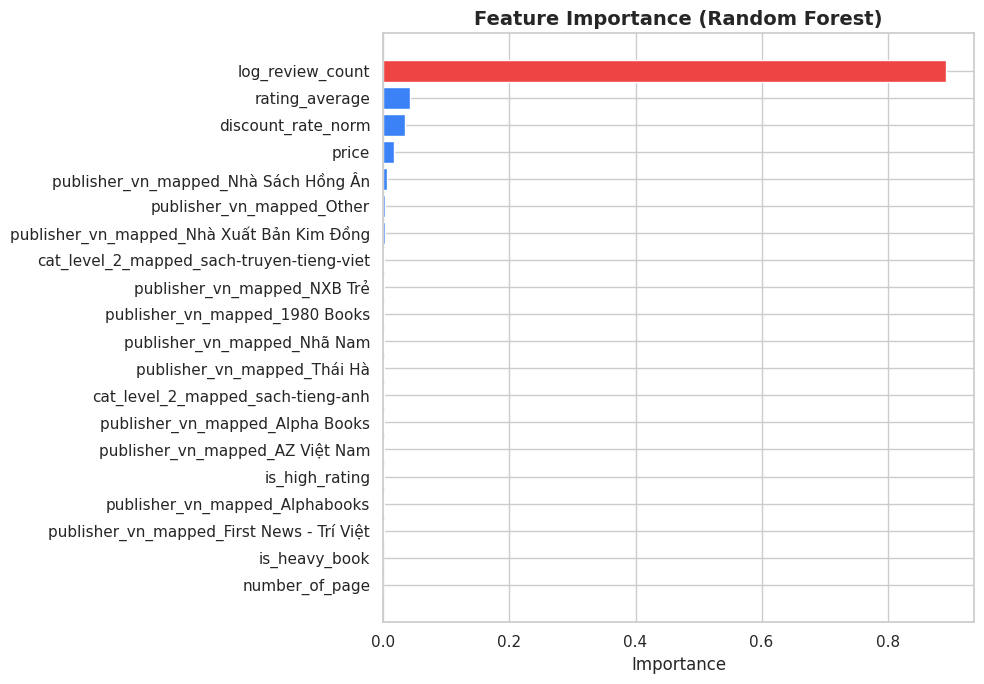


Top 5 features:
  publisher_vn_mapped_Nhà Sách Hồng Ân    : 0.0053
  price                                   : 0.0174
  discount_rate_norm                      : 0.0343
  rating_average                          : 0.0416
  log_review_count                        : 0.8925


In [7]:
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'feature': ml_features, 'importance': importances}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, max(6, len(feat_imp)*0.35)))
colors = ['#3b82f6' if imp < 0.05 else '#ef4444' if imp > 0.1 else '#f59e0b' for imp in feat_imp['importance']]
plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors, edgecolor='white')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for _, row in feat_imp.tail(5).iterrows():
    print(f"  {row['feature']:40s}: {row['importance']:.4f}")


---
## 4. KMeans Clustering — Phân khúc sách


### 4.1 Chuẩn bị data cho clustering
Dùng data EDA (chưa scale) với 4 features: `log_sales`, `rating_average`, `price`, `review_count`


In [8]:
df_eda = pd.read_csv("../../data/processed/data_eda.csv", low_memory=False)

# Tạo features cho clustering
cluster_features = ['rating_average', 'price', 'review_count']
df_eda['log_sales_cl'] = np.log1p(df_eda['all_time_quantity_sold'].fillna(0))
cluster_cols = ['log_sales_cl'] + cluster_features

X_cluster = df_eda[cluster_cols].fillna(0).copy()
print(f"Clustering data shape: {X_cluster.shape}")
X_cluster.describe()


Clustering data shape: (132955, 4)


,log_sales_cl,rating_average,price,review_count
count,132955.000000,132955.000000,1.329550e+05,132955.000000
mean,1.231466,1.143218,1.803609e+05,6.110774
std,1.700202,2.060529,2.125998e+05,79.503230
min,0.000000,0.000000,0.000000e+00,0.000000
25%,0.000000,0.000000,8.000000e+04,0.000000
50%,0.693147,0.000000,1.348000e+05,0.000000
75%,1.945910,0.000000,2.130000e+05,0.000000
max,11.229010,5.000000,9.990000e+06,7257.000000


### 4.2 Scale & Elbow Method


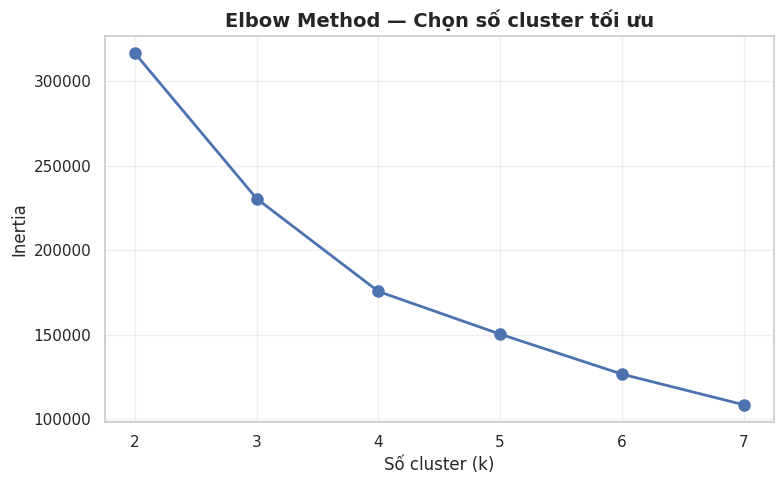

=> Chọn k=4 (điểm elbow rõ ràng nhất)


In [9]:
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# Elbow method
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Số cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Chọn số cluster tối ưu', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=> Chọn k=4 (điểm elbow rõ ràng nhất)")


### 4.3 Train KMeans (k=4)


In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_eda['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("Cluster distribution:")
print(df_eda['cluster'].value_counts().sort_index())

print("\n=== Cluster Profiling ===")
cluster_profile = df_eda.groupby('cluster')[['all_time_quantity_sold', 'rating_average', 'price', 'review_count']].agg(['mean', 'median', 'count'])
print(cluster_profile)


Cluster distribution:
cluster
0     2819
1    30942
2       78
3    99116
Name: count, dtype: int64

=== Cluster Profiling ===
        all_time_quantity_sold                 rating_average                \
                          mean   median  count           mean median  count   
cluster                                                                       
0                     4.892515      0.0   2819       0.558851    0.0   2819   
1                   176.996768     32.0  30942       4.831837    5.0  30942   
2                 19642.820513  15959.0     78       4.843590    4.8     78   
3                     1.725857      0.0  99116       0.005415    0.0  99116   

                price                  review_count                 
                 mean    median  count         mean  median  count  
cluster                                                             
0        1.126581e+06  892800.0   2819     0.753104     0.0   2819  
1        1.453689e+05  115000.0  30942    1

### 4.4 Visualize Clusters


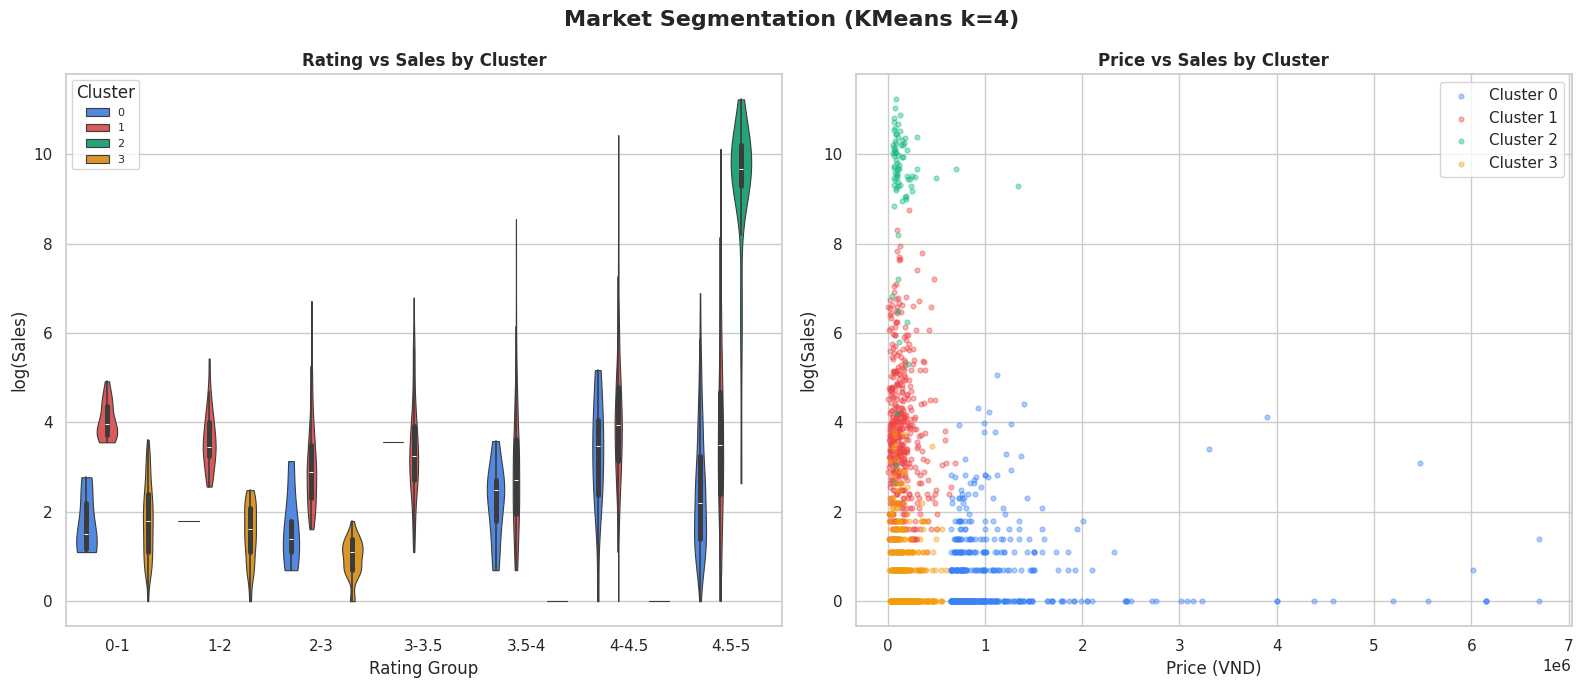

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b']

# Rating vs Sales — violin vì rating_average discrete (bước 0.5)
rating_bins = [0, 1, 2, 3, 3.5, 4, 4.5, 5.1]
rating_labels = ['0-1', '1-2', '2-3', '3-3.5', '3.5-4', '4-4.5', '4.5-5']
df_eda['rating_bin'] = pd.cut(df_eda['rating_average'], bins=rating_bins, labels=rating_labels)
df_eda['log_sales_plot'] = np.log1p(df_eda['all_time_quantity_sold'])
cluster_palette = {c: colors[c] for c in sorted(df_eda['cluster'].unique())}
sns.violinplot(data=df_eda, x='rating_bin', y='log_sales_plot', hue='cluster',
               palette=cluster_palette, ax=axes[0], inner='box', linewidth=0.8, cut=0)
axes[0].set_xlabel('Rating Group')
axes[0].set_ylabel('log(Sales)')
axes[0].set_title('Rating vs Sales by Cluster', fontweight='bold')
axes[0].legend(title='Cluster', fontsize=8)

# Price vs Sales
for c in sorted(df_eda['cluster'].unique()):
    subset = df_eda[df_eda['cluster']==c].sample(min(500, len(df_eda[df_eda['cluster']==c])), random_state=42)
    axes[1].scatter(subset['price'], np.log1p(subset['all_time_quantity_sold']),
                   alpha=0.4, s=12, c=colors[c], label=f'Cluster {c}')
axes[1].set_xlabel('Price (VND)')
axes[1].set_ylabel('log(Sales)')
axes[1].set_title('Price vs Sales by Cluster', fontweight='bold')
axes[1].legend()

plt.suptitle('Market Segmentation (KMeans k=4)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.5 Đặt tên cho từng Cluster


In [12]:
cluster_means = df_eda.groupby('cluster')[['all_time_quantity_sold', 'rating_average', 'price', 'review_count']].mean()

# Đặt tên dựa trên rank tương đối (tránh dùng ngưỡng tuyệt đối → 2 cluster cùng tên)
sales_ranked = cluster_means['all_time_quantity_sold'].rank(ascending=False)
reviews_ranked = cluster_means['review_count'].rank(ascending=False)
rating_ranked = cluster_means['rating_average'].rank(ascending=False)

cluster_labels = {}
for c in cluster_means.index:
    sales_rank = sales_ranked[c]
    rev_rank = reviews_ranked[c]
    rat_rank = rating_ranked[c]
    if sales_rank == 1 and rev_rank <= 2:
        cluster_labels[c] = " Best Seller"
    elif rat_rank == 1 and sales_rank >= 3:
        cluster_labels[c] = " Niche (High Rating, Low Sales)"
    elif sales_rank == 4:
        cluster_labels[c] = " Low Performer"
    else:
        cluster_labels[c] = " Normal"

print("=== Cluster Naming ===")
for c in sorted(cluster_means.index):
    row = cluster_means.loc[c]
    print(f"  Cluster {c} → {cluster_labels[c]}")
    print(f"    avg_sales={row['all_time_quantity_sold']:.0f}, avg_rating={row['rating_average']:.2f}, avg_reviews={row['review_count']:.0f}")


=== Cluster Naming ===
  Cluster 0 →  Normal
    avg_sales=5, avg_rating=0.56, avg_reviews=1
  Cluster 1 →  Normal
    avg_sales=177, avg_rating=4.83, avg_reviews=19
  Cluster 2 →  Best Seller
    avg_sales=19643, avg_rating=4.84, avg_reviews=2649
  Cluster 3 →  Low Performer
    avg_sales=2, avg_rating=0.01, avg_reviews=0


---
## 5. Save Artifacts


In [13]:
artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

# Random Forest model
joblib.dump(rf_model, os.path.join(artifacts_dir, 'rf_model.pkl'))

# KMeans model + scaler
joblib.dump(kmeans, os.path.join(artifacts_dir, 'kmeans_model.pkl'))
joblib.dump(cluster_scaler, os.path.join(artifacts_dir, 'cluster_scaler.pkl'))

# Metadata (features, top categories)
joblib.dump(metadata, os.path.join(artifacts_dir, 'ml_metadata.pkl'))

# Feature importance
feat_imp.to_csv(os.path.join(artifacts_dir, 'feature_importance.csv'), index=False)

print("=" * 50)
print("ALL ARTIFACTS SAVED!")
print("=" * 50)
print(f"\nnotebooks/model/artifacts/")
print(f"  ├── rf_model.pkl")
print(f"  ├── kmeans_model.pkl")
print(f"  ├── cluster_scaler.pkl")
print(f"  ├── ml_metadata.pkl")
print(f"  └── feature_importance.csv")


ALL ARTIFACTS SAVED!

notebooks/model/artifacts/
  ├── rf_model.pkl
  ├── kmeans_model.pkl
  ├── cluster_scaler.pkl
  ├── ml_metadata.pkl
  └── feature_importance.csv
